In [2]:
%load_ext autoreload
%autoreload 2

In [104]:
import sys
sys.path.append("../")
import pandas as pd
from utils import ca as cu, behave as bu, plot as pu, db as db
import numpy as np
from paths.config import M2PConfig
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import ranksums, spearmanr, skewnorm
from scipy.ndimage import gaussian_filter1d
from scipy.stats import ranksums, wilcoxon
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

ModuleNotFoundError: No module named 'seaborn'

In [90]:
COLOR_PENK = (0, 0, 1, 1)
COLOR_NONPENK = (1, 0, 0, 1)

LINEWIDTH_HIST = 3
LINEWIDTH_FIT = 3

RESPONSE_TYPE = 'deconv_norm'
RESPONSE_TYPE_ABR = 'norm. deconv.'
# Guassian smooth in frames
RESPONSE_SIGMA = 3

COL_CORR_TRANS_RHO = "trans_corr_rho"
COL_CORR_TRANS_P = "trans_corr_rp"
COL_CORR_ROT_RHO = "rot_corr_rho"
COL_CORR_ROT_P = "rot_corr_rp"
COL_CORR_TRANS_ROT_DIFF_RHO = "trans_rot_diff_corr_rho"

filter_size=5,
grad_win_time=0.2,
min_periods=2,
center_win=True

In [91]:
cfg = M2PConfig()
df_exps, df_roi, df_ca, df_behave, df_behave_ca = db.get_ca_behave_data(cfg)

In [92]:
grp_df_cell = df_behave_ca.groupby(['exp_id', 'roi_id', 'celltype'])

# Calculate correlations and put in roi table

(0.0, 0.0, 0.0, 0.0, 0.0)

[ 1.91222807e+03  1.18188035e-03  1.36705599e+02  1.44152647e-01
 -5.56863133e+00] -1.2750988737461513


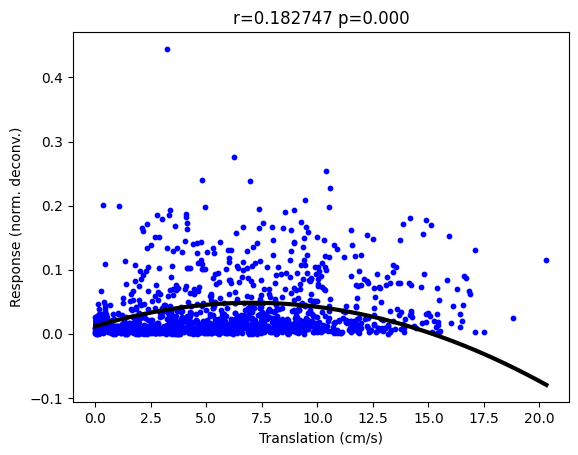

In [106]:
def skewed_gaussian(x, a, mu, sigma, alpha, offset):
    return a * skewnorm.pdf(x, alpha, loc=mu, scale=sigma) + offset

for (exp_id, roi_id, cell_type), group in grp_df_cell:
    
    data_trans = group[bu.SPEED_FILT_GRAD]
    data_rot = group[bu.AHV_FILT_GRAD].abs()
    #data_resp = gaussian_filter1d(group[RESPONSE_TYPE], sigma=RESPONSE_SIGMA)
    data_resp = group[RESPONSE_TYPE]

    # Resample to 1sec
    new_length = len(data_trans) // 10
    data_trans = data_trans.values.reshape(new_length, -1).mean(axis=1)
    data_rot = data_rot.values.reshape(new_length, -1).mean(axis=1)
    data_resp = data_resp.values.reshape(new_length, -1).mean(axis=1)
    
    corr_trans = spearmanr(data_trans, data_resp)
    corr_rot = spearmanr(data_rot, data_resp)
    
    roi_index = np.logical_and(df_roi["exp_id"] == exp_id, df_roi["roi_id"] == roi_id)

    df_roi.loc[roi_index, COL_CORR_TRANS_RHO] = corr_trans.statistic
    df_roi.loc[roi_index, COL_CORR_TRANS_P] = corr_trans.pvalue
    df_roi.loc[roi_index, COL_CORR_ROT_RHO] = corr_rot.statistic
    df_roi.loc[roi_index, COL_CORR_ROT_P] = corr_rot.pvalue
    
    initial_guess = (1, 0.5, 2, 1, 0.1)
    lower_bounds = [0, 0, 0, 0, -np.inf]
    upper_bounds = [np.inf, np.inf, np.inf, np.inf, np.inf]
    
    zv = np.logical_or(data_resp==0, data_trans==0)
    data_trans = data_trans[~zv]
    data_resp = data_resp[~zv]
    

    # Fit the skewed Gaussian function to the data
    popt, _ = curve_fit(skewed_gaussian, 
                        data_trans, 
                        data_resp, 
                        p0=initial_guess, 
                        maxfev=100000,
                        bounds=(lower_bounds, upper_bounds))
    a_fit, mu_fit, sigma_fit, alpha_fit, offset_fit = popt
    
    x_fit_plot = np.linspace(np.min(data_trans), np.max(data_trans), 100)
    y_fit_plot = skewed_gaussian(x_fit, a_fit, mu_fit, sigma_fit, alpha_fit, offset_fit)
    y_fit = skewed_gaussian(data_trans, a_fit, mu_fit, sigma_fit, alpha_fit, offset_fit)
    
    r_squared = r2_score(data_trans, y_fit)
    
    print(popt, r_squared)
    
    c = COLOR_PENK
    if cell_type == 'nonpenk':
        c = COLOR_NONPENK
        
    fig, ax = plt.subplots()
    
    plt.scatter(data_trans, 
                data_resp,
                s=10,
                color=c)
    
    plt.plot(x_fit_plot, 
             y_fit_plot,
             'k',
             linewidth=LINEWIDTH_FIT)
    
    plt.xlabel('Translation (cm/s)')
    plt.ylabel('Response ({})'.format(RESPONSE_TYPE_ABR))
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    plt.title("r={:2f} p={:.3f}".format(res.statistic, res.pvalue))
    plt.show()
    plt.close()
    
    

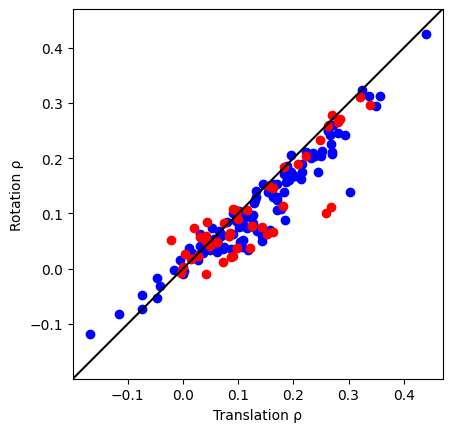

WilcoxonResult(statistic=909.0, pvalue=6.262669240152145e-13)
WilcoxonResult(statistic=253.0, pvalue=0.0013064878837667493)


Text(0, 0.5, 'Fraction of cells')

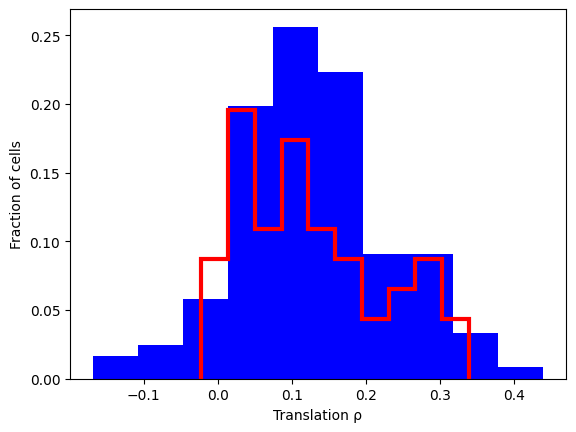

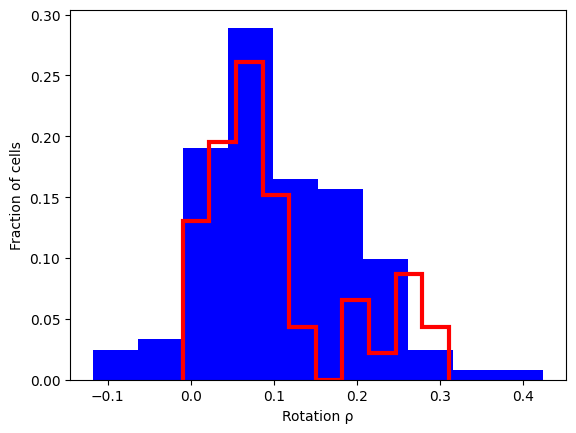

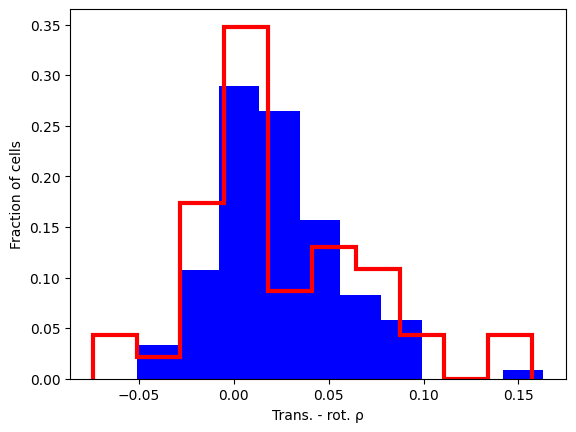

In [71]:

penk_indexes = df_roi["celltype"] == "penk"
nonpenk_indexes = ~penk_indexes
    
# Plot the main response against the null response.
plt.figure()
plt.scatter(df_roi.loc[penk_indexes][COL_CORR_TRANS_RHO],
            df_roi.loc[penk_indexes][COL_CORR_ROT_RHO],
            color=COLOR_PENK, label="penk")
plt.scatter(df_roi.loc[nonpenk_indexes][COL_CORR_TRANS_RHO],
            df_roi.loc[nonpenk_indexes][COL_CORR_ROT_RHO],
            color=COLOR_NONPENK, label="nonpenk")
pu.square_plot()
plt.xlabel("Translation ρ")
plt.ylabel("Rotation ρ")
plt.show()
plt.close()

result = wilcoxon(df_roi.loc[penk_indexes][COL_CORR_TRANS_RHO], 
                  df_roi.loc[penk_indexes][COL_CORR_ROT_RHO])
print(result)
result = wilcoxon(df_roi.loc[nonpenk_indexes][COL_CORR_TRANS_RHO], 
                  df_roi.loc[nonpenk_indexes][COL_CORR_ROT_RHO])
print(result)

# Calculate and index and plot a histgram
df_roi[COL_CORR_TRANS_ROT_DIFF_RHO] = df_roi[COL_CORR_TRANS_RHO] - df_roi[COL_CORR_ROT_RHO]

# Translation
plt.figure()
hist_data = df_roi.loc[penk_indexes][COL_CORR_TRANS_RHO]
plt.hist(hist_data, 
         color=COLOR_PENK, label="penk",
         weights=np.ones(len(hist_data)) / len(hist_data))
hist_data = df_roi.loc[nonpenk_indexes][COL_CORR_TRANS_RHO]
plt.hist(hist_data, color=COLOR_NONPENK, 
         label="nonpenk",
         weights=np.ones(len(hist_data)) / len(hist_data),
         histtype=u'step',
         linewidth=LINEWIDTH_HIST)
plt.xlabel("Translation ρ")
plt.ylabel("Fraction of cells")

# Rotation
plt.figure()
hist_data = df_roi.loc[penk_indexes][COL_CORR_ROT_RHO]
plt.hist(hist_data, 
         color=COLOR_PENK, label="penk",
         weights=np.ones(len(hist_data)) / len(hist_data))
hist_data = df_roi.loc[nonpenk_indexes][COL_CORR_ROT_RHO]
plt.hist(hist_data, color=COLOR_NONPENK, 
         label="nonpenk",
         weights=np.ones(len(hist_data)) / len(hist_data),
         histtype=u'step',
         linewidth=LINEWIDTH_HIST)
plt.xlabel("Rotation ρ")
plt.ylabel("Fraction of cells")

# Translation - rotation
plt.figure()
hist_data = df_roi.loc[penk_indexes][COL_CORR_TRANS_ROT_DIFF_RHO]
plt.hist(hist_data, 
         color=COLOR_PENK, label="penk",
         weights=np.ones(len(hist_data)) / len(hist_data))
hist_data = df_roi.loc[nonpenk_indexes][COL_CORR_TRANS_ROT_DIFF_RHO]
plt.hist(hist_data, color=COLOR_NONPENK, 
         label="nonpenk",
         weights=np.ones(len(hist_data)) / len(hist_data),
         histtype=u'step',
         linewidth=LINEWIDTH_HIST)
plt.xlabel("Trans. - rot. ρ")
plt.ylabel("Fraction of cells")